# Build your network

Variational wavefunctions in Quantax are built on [Equinox](https://github.com/patrick-kidger/equinox).
In this tutorial, we will introduce how to build your network on Equinox, and how to test the performance of your network in Quantax.

Reference:

[Equinox: neural networks in JAX via callable PyTrees and filtered transformations](https://arxiv.org/abs/2111.00254)

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import quantax as qtx
import matplotlib.pyplot as plt

L = 8

## Equinox quick start

Equinox is a minimalist neural network library built directly on top of JAX. Unlike Flax and Haiku, which come with higher-level abstractions, Equinox emphasizes flexibility and transparency: everything is just PyTrees and functions, making it easy to integrate with raw JAX code. This means you don’t have to fight against the framework when experimenting with unconventional architectures, physics-inspired models, or custom training loops.

A customized Equinox network usually looks like this.

In [2]:
import equinox as eqx

class Linear(eqx.Module):
    weight: jax.Array
    bias: jax.Array

    def __init__(self, in_size, out_size, key):
        wkey, bkey = jr.split(key)
        self.weight = jr.normal(wkey, (out_size, in_size))
        self.bias = jr.normal(bkey, (out_size,))

    def __call__(self, x):
        return self.weight @ x + self.bias
    
key = jr.key(0)
linear = Linear(2, 3, key)
print(linear)

Linear(weight=f32[3,2], bias=f32[3])


`eqx.Module` has two important properties.

1. It's a PyTree. In this example, `weight` and `bias` are leaves on this PyTree.

In [3]:
print("weight:", linear.weight)
print("bias:", linear.bias)

vals, treedef = jax.tree.flatten(linear)
print("Flattened leaves:", vals)

weight: [[ 1.0040143  -0.9063372 ]
 [-0.7481722  -1.1713669 ]
 [-0.8712328   0.58883816]]
bias: [-2.4424558  -2.0356805   0.20554423]
Flattened leaves: [Array([[ 1.0040143 , -0.9063372 ],
       [-0.7481722 , -1.1713669 ],
       [-0.8712328 ,  0.58883816]], dtype=float32), Array([-2.4424558 , -2.0356805 ,  0.20554423], dtype=float32)]


2. It's callable, since the `__call__` method is defined in this object.

In [4]:
inputs = jnp.array([1.0, 2.0])
outputs = linear(inputs)

jitted_fn = jax.jit(lambda linear, x: linear(x))  # `linear` is jittable as it's a PyTree
jitted_outputs = jitted_fn(linear, inputs)
jacobian = jax.jacrev(jitted_fn)(linear, inputs)

print("outputs:", outputs)
print("jitted outputs:", jitted_outputs)
print("jacobian:", jacobian)

outputs: [-3.2511158  -5.126587    0.51198775]
jitted outputs: [-3.2511158  -5.126587    0.51198775]
jacobian: Linear(weight=f32[3,3,2], bias=f32[3,3])


Apart from that, Equinox provides convenient filtered functions like `filter_jit` for PyTree. It's similar to `jax.jit` but available for PyTrees with non-jittable leaves. See the code below for example. In Quantax, we use these filtered functions for better flexibility.

In [5]:
def summation(l):
    return sum(jnp.sum(x) for x in l if isinstance(x, jax.Array))

l = [1, 2.0, jnp.array([1.0, 2.0]), "string", jnp.array([3.0, 4.0])]

try:
    out = jax.jit(summation)(l)
except TypeError as e:
    print("`jax.jit` failed due to non-jittable string data type in the list.")

out = eqx.filter_jit(summation)(l)
print("eqx.filter_jit successful, output: ", out)

try:
    g = jax.grad(summation)(l)
except TypeError as e:
    print("`jax.grad` failed due to non-jittable string data type in the list.")

g = eqx.filter_grad(summation)(l)
print("eqx.filter_grad successful, gradient: ", g)

`jax.jit` failed due to non-jittable string data type in the list.


eqx.filter_jit successful, output:  10.0
`jax.grad` failed due to non-jittable string data type in the list.


eqx.filter_grad successful, gradient:  [None, None, Array([1., 1.], dtype=float32), None, Array([1., 1.], dtype=float32)]


## Build wavefunction

Let's start by building the following variational wavefunction

$$
\begin{aligned}
x^{(1)} &= \mathrm{ReLU}(W^{(1)} s + b^{(1)}) \\
x^{(2)} &= W^{(2)} x^{(1)} + b^{(2)} \\
\psi &= \sum \exp(x^{(2)})
\end{aligned}
$$
where the network has an array input $s$ and a scalar output $\psi$, and $W^{(1)}$, $b^{(1)}$, $W^{(2)}$, and $b^{(2)}$ are variational parameters.

In [6]:
import equinox as eqx

class MyModel(eqx.Module):
    layer1: eqx.nn.Linear  # eqx.nn.Linear is a built-in linear layer
    layer2: eqx.nn.Linear

    def __init__(self, in_size: int, width: int):
        keys = qtx.get_subkeys(2)  # Convenient function in Quantax to provide keys
        layer1 = eqx.nn.Linear(in_size, width, key=keys[0])
        self.layer1 = qtx.nn.apply_he_normal(keys[0], layer1)  # He initialization
        layer2 = eqx.nn.Linear(width, width, key=keys[1])
        self.layer2 = qtx.nn.apply_lecun_normal(keys[1], layer2)  # LeCun initialization

    def __call__(self, x):
        x = jax.nn.relu(self.layer1(x))
        x = self.layer2(x)
        psi = jnp.sum(jnp.exp(x))
        return psi

model = MyModel(in_size=L, width=16)
print(model)

MyModel(
  layer1=Linear(
    weight=f32[16,8],
    bias=f32[16],
    in_features=8,
    out_features=16,
    use_bias=True
  ),
  layer2=Linear(
    weight=f32[16,16],
    bias=f32[16],
    in_features=16,
    out_features=16,
    use_bias=True
  )
)


We can test it by making a forward pass.

In [7]:
s = jnp.ones(L)
psi = model(s)
print("psi =", psi)

psi = 33.11075


Now let's use this new network in Quantax. One should wrap the network by {py:class}`~quantax.state.Variational` to use it as a variational state. It supports batched forward pass.

In [8]:
lattice = qtx.sites.Chain(L)
state = qtx.state.Variational(model)

print("Number of parameters:", state.nparams)

s = qtx.utils.rand_states(8)  # 8 random spin configurations
psi = state(s)  # Batched forward pass
print("psi =", psi)

Number of parameters: 416


psi = [21.656624 30.482227 64.64798  16.680628 18.125128 18.14464  22.116062
 15.734102]


## Test by exact reconfiguration

Exact reconfiguration (ER) is an optimization method that approximates imaginary-time evolution without Monte Carlo samples, which is only available in small systems. We can use {py:class}`~quantax.optimizer.ER` to rapidly test the expressive power of neural networks.

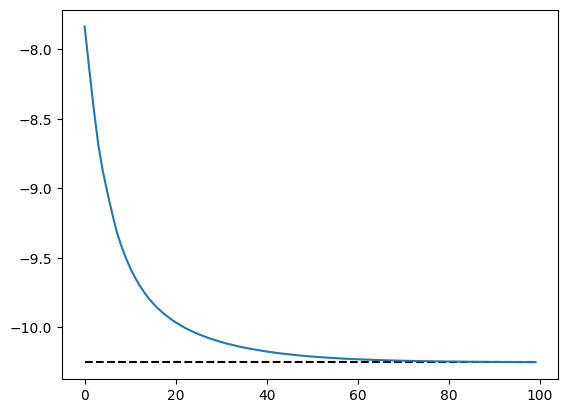

In [9]:
H = qtx.operator.Ising(h=1.0)
E, wf = H.diagonalize()
exact_state = qtx.state.DenseState(wf)

optimizer = qtx.optimizer.ER(state, H)

energy = qtx.utils.DataTracer()
training_rate = 0.02

for i in range(100):
    step = optimizer.get_step()
    state.update(step * training_rate)
    energy.append(optimizer.energy)

energy.plot(baseline=E)
plt.show()

In small systems, we can transform {py:class}`~quantax.state.Variational` to {py:class}`~quantax.state.DenseState` to check its overlap with the exact ground state.

In [10]:
dense = state.todense().normalize()
overlap = abs(dense @ exact_state)
print("Overlap with the exact ground state:", overlap)

Overlap with the exact ground state: 0.9980396628379822


Now we have a nice neural quantum state for solving the Ising model!

## Avoid overflow

In neural quantum state simulations, we often have very large wavefunctions beyond the range of float64. Here is an example.

In [11]:
model = MyModel(in_size=L, width=16)

W1 = model.layer1.weight
W2 = model.layer2.weight

# Manually multiply weights by 100 to cause overflow
model = eqx.tree_at(lambda model: model.layer1.weight, model, W1 * 100)
model = eqx.tree_at(lambda model: model.layer2.weight, model, W2 * 100)

s = qtx.utils.rand_states()
model(s)

Array(inf, dtype=float32)

To avoid this problem, we define two customized data types to store large values, which are also accepted as network outputs in Quantax. Both keep the magnitude and exponent separately, so values beyond the range of float64 can be represented.

- {py:class}`~quantax.utils.LogArray`: value $= \mathrm{sign} \cdot e^{\mathrm{logabs}}$, a PyTree of `sign` ($\pm 1$ or a complex phase) and real `logabs`.

- {py:class}`~quantax.utils.ScaleArray`: value $= \mathrm{significand} \cdot e^{\mathrm{exponent}}$, a PyTree of `significand` and `exponent`. $|\mathrm{significand}|$ is not enforced to be 1 so that `ScaleArray` passes more smoothly through 0.

Instead of using dangerous functions like `jnp.exp` that might cause overflow, one can use {py:func}`~quantax.nn.exp_by_scale` to output safe values expressed by {py:class}`~quantax.utils.ScaleArray`.

In [12]:
class NewModel(eqx.Module):
    layer1: eqx.nn.Linear
    layer2: eqx.nn.Linear

    def __init__(self, in_size: int, width: int):
        keys = qtx.get_subkeys(2)
        layer1 = eqx.nn.Linear(in_size, width, key=keys[0])
        self.layer1 = qtx.nn.apply_he_normal(keys[0], layer1)
        layer2 = eqx.nn.Linear(width, width, key=keys[1])
        self.layer2 = qtx.nn.apply_lecun_normal(keys[1], layer2)

    def __call__(self, x):
        x = jax.nn.relu(self.layer1(x))
        x = self.layer2(x)
        # Dangerous: psi = jnp.sum(jnp.exp(x))
        # Safe:
        psi = qtx.nn.exp_by_scale(x).sum()
        return psi
    

model = NewModel(in_size=L, width=16)
model = eqx.tree_at(lambda model: model.layer1.weight, model, W1 * 100)
model = eqx.tree_at(lambda model: model.layer2.weight, model, W2 * 100)

psi = model(s)
print(psi)

ScaleArray(
  significand=1.0,
  exponent=14163.599609375
)


Here the output {py:class}`~quantax.utils.ScaleArray` is a PyTree with significand $x$ and exponent $\theta$. The true expressed value is $x e^\theta$, which is beyond the range of float64. In most calculations, this quantity can be treated like an ordinary array object, as shown below.

In [13]:
psi = psi.repeat(8).reshape(2, 4)
print("Reshape psi:", psi)

psi = psi.sum(axis=1)
print("Sum psi:", psi)

psi = psi ** (1 / 10000)
print("Power psi:", psi)

psi = jnp.asarray(psi)
print("To jax Array:", psi)

Reshape psi: ScaleArray(
  significand=[[1. 1. 1. 1.]
 [1. 1. 1. 1.]],
  exponent=[[14163.6 14163.6 14163.6 14163.6]
 [14163.6 14163.6 14163.6 14163.6]]
)


Sum psi: ScaleArray(
  significand=[4. 4.],
  exponent=[14163.6 14163.6]
)


Power psi: ScaleArray(
  significand=[1.0001386 1.0001386],
  exponent=[1.4163599 1.4163599]
)


To jax Array: [4.1226597 4.1226597]


However, JAX doesn't have full support for [customized arrays](https://docs.jax.dev/en/latest/jep/28661-jax-array-protocol.html), so one should be careful when using these customized arrays. Here we list several possible problems.

1. Manipulations like `jnp.fn(array)` transform customized arrays to `jax.Array`, causing overflow. To avoid it, call `array.fn()`.

2. Computations like `jax_array * customized_array` always call `jax_array.__mul__(customized_array)`, which returns a `jax.Array` that might cause overflow. To avoid it, use `customized_array * jax_array`.

Here are some examples

In [14]:
significand = jnp.array([0.0, 1.0, 2.0, 3.0])
exponent = jnp.array([10000.0, 10000.0, 10000.0, 10000.0])
psi = qtx.utils.ScaleArray(significand, exponent)

print("Wrong sum:", jnp.sum(psi))
print("Correct sum:", psi.sum())

a = jnp.arange(4)
print("Wrong mul:", a * psi)
print("Correct mul:", psi * a)

Wrong sum: nan


Correct sum: ScaleArray(
  significand=6.0,
  exponent=10000.0
)


Wrong mul: [nan inf inf inf]


Correct mul: ScaleArray(
  significand=[0. 1. 4. 9.],
  exponent=[10000. 10000. 10000. 10000.]
)
